# Analysis of the ALADIN results

In [184]:
import os
from pathlib import Path

p = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()

while not (p / "ALADIN").exists():   # or any marker file
    if p.parent == p:
        raise RuntimeError("Project root not found")
    p = p.parent
os.chdir(os.path.join(p, "ALADIN"))
print("CWD set to project root:", p)

CWD set to project root: /workspaces


In [185]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.patches import Patch


In [186]:
BYTES_PER_KB = 1024.0
SAVE_FIGURES = False

LABEL_FONT_SIZE = 28
TICK_FONT_SIZE = 20
X_TICK_FONT_SIZE = 20
LEGEND_FONT_SIZE = 16

plt.rcParams.update({
    "font.family": "serif",
    "font.size": TICK_FONT_SIZE,
    "axes.labelsize": LABEL_FONT_SIZE,
    "xtick.labelsize": X_TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 1.2,
    "hatch.linewidth": 1.5,
})

CASE_COLORS = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
]

model_alias = {
    "mobilenet_v1": "MobileNetV1",
    "vgg": "VGG",
    "resnt": "ResNet",
    "efficientnet": "EfficientNet",
    "shufflenet": "ShuffleNet"
}

## Implementation-aware analysis

In [187]:

model_name = "efficientnet"
pattern = f"./output/STEP1_{model_name}_*.csv"

FIGURE_SIZE = (15, 10)


# ================================================================
# Implementation styles
# ================================================================
IMPLEMENTATION_STYLES = {
    "default": {
        "hatch": "",
        "label": "Default",
    },
    "lut": {
        "hatch": "/",          # instead of "///"
        "label": "LUT",
    },
    "thresholds": {
        "hatch": "\/",          # instead of "xxx"
        "label": "Thresholds",
    },
    "lut+thresholds": {
        "hatch": "xx",         # instead of "///xxx"
        "label": "LUT + Thresholds",
    },
}


### plot setup

In [188]:


files = sorted(glob.glob(pattern))

if not files:
    raise FileNotFoundError(
        f"No CSV files match:\n{pattern}"
    )


# ================================================================
# Load CSV files
# ================================================================
required_columns = [
    "Op.",
    "MACs",
    "Memory",
    "BOPs",
    "implementation",
]

filename_prefix = f"STEP1_{model_name}_"

configs = []
dataframes = []

for filepath in files:
    filename = os.path.basename(filepath)
    stem = os.path.splitext(filename)[0]

    if stem.startswith(filename_prefix):
        config_name = stem[len(filename_prefix):]
    else:
        config_name = stem


    config_name = config_name.replace("case", "case ").strip()
    df = pd.read_csv(filepath)

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
    )

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{filepath} is missing columns: {missing_columns}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df = df.copy()

    # Preserve exact CSV row order
    df["Op."] = (
        df["Op."]
        .astype(str)
        .str.strip()
    )

    # Normalize implementation names
    df["implementation"] = (
        df["implementation"]
        .fillna("default")
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "threshold": "thresholds",
            "thresh": "thresholds",
            "lookup table": "lut",
            "lookup_table": "lut",
            "none": "default",
            "nan": "default",
            "": "default",
        })
    )

    for metric in ["MACs", "Memory", "BOPs"]:
        df[metric] = pd.to_numeric(
            df[metric],
            errors="coerce"
        )

    invalid_rows = df[
        df[["MACs", "Memory", "BOPs"]]
        .isna()
        .any(axis=1)
    ]

    if not invalid_rows.empty:
        raise ValueError(
            f"Invalid numeric values in:\n{filepath}\n\n"
            f"{invalid_rows}"
        )

    valid_implementations = {
        "default",
        "lut",
        "thresholds",
    }

    unknown_implementations = sorted(
        set(df["implementation"].unique())
        - valid_implementations
    )

    if unknown_implementations:
        raise ValueError(
            f"Unknown implementation values in:\n{filepath}\n"
            f"{unknown_implementations}"
        )

    configs.append(config_name)
    dataframes.append(df)



In [189]:

# ================================================================
# Validate layer names and CSV order
# ================================================================
reference_operations = dataframes[0]["Op."].tolist()

for filepath, df in zip(files[1:], dataframes[1:]):
    if df["Op."].tolist() != reference_operations:
        raise ValueError(
            f"Layer names or order in:\n{filepath}\n"
            "do not match the first CSV file."
        )


num_configs = len(configs)

if num_configs > len(CASE_COLORS):
    raise ValueError(
        f"The palette supports {len(CASE_COLORS)} cases, "
        f"but {num_configs} files were found."
    )

colors = CASE_COLORS[:num_configs]



In [190]:
# ================================================================
# Assign layers to computational blocks
#
# Conv + following Relu/Quant -> one block
# Gemm + following Quant      -> one block
# MaxPool + following Quant   -> one block
# ================================================================
def operation_type(operation_name):
    return operation_name.split("_", 1)[0].strip().lower()


block_start_types = {
    "conv",
    "gemm",
    "maxpool",
}

block_ids = []
current_block = -1

for operation_name in reference_operations:
    op_type = operation_type(operation_name)

    if op_type in block_start_types:
        current_block += 1

    if current_block < 0:
        current_block = 0

    block_ids.append(current_block)

block_ids = np.asarray(block_ids, dtype=int)
num_blocks = int(block_ids.max()) + 1


# ================================================================
# Generate block labels
# ================================================================
block_labels = []

for block_id in range(num_blocks):
    indices = np.flatnonzero(
        block_ids == block_id
    )

    first_operation = reference_operations[
        indices[0]
    ]

    block_labels.append(first_operation)

block_labels = np.asarray(
    block_labels,
    dtype=str
)


# ================================================================
# Determine implementation type for each block
# ================================================================
def classify_block_implementation(values):
    implementations = set(values)

    # Ignore default if a specialized implementation is present
    implementations.discard("default")

    contains_lut = "lut" in implementations
    contains_thresholds = "thresholds" in implementations

    if contains_lut and contains_thresholds:
        return "lut+thresholds"

    if contains_lut:
        return "lut"

    if contains_thresholds:
        return "thresholds"

    return "default"


# ================================================================
# Aggregate layers by computational block
# ================================================================
aggregated_dataframes = []

for df in dataframes:
    working_df = df.copy()
    working_df["block_id"] = block_ids

    metric_summary = (
        working_df
        .groupby(
            "block_id",
            sort=False
        )[["MACs", "Memory", "BOPs"]]
        .sum()
    )

    implementation_summary = (
        working_df
        .groupby(
            "block_id",
            sort=False
        )["implementation"]
        .apply(classify_block_implementation)
    )

    aggregated_df = metric_summary.copy()

    aggregated_df["implementation"] = (
        implementation_summary
    )

    aggregated_df["Block"] = block_labels

    aggregated_dataframes.append(
        aggregated_df.reset_index(drop=True)
    )



In [191]:
# ================================================================
# Build arrays
# Shape: cases × blocks
# ================================================================
mac_values = np.vstack([
    df["MACs"].to_numpy(dtype=float)
    for df in aggregated_dataframes
])

memory_values_kb = np.vstack([
    df["Memory"].to_numpy(dtype=float) / BYTES_PER_KB
    for df in aggregated_dataframes
])

bops_values = np.vstack([
    df["BOPs"].to_numpy(dtype=float)
    for df in aggregated_dataframes
])

block_implementations = np.vstack([
    df["implementation"].to_numpy(dtype=str)
    for df in aggregated_dataframes
])


# ================================================================
# Filter zero-MAC blocks only from the MACs plot
# ================================================================
nonzero_mac_mask = np.any(
    mac_values > 0,
    axis=0
)

mac_plot_values = mac_values[
    :,
    nonzero_mac_mask
]

mac_plot_labels = block_labels[
    nonzero_mac_mask
]

mac_plot_implementations = block_implementations[
    :,
    nonzero_mac_mask
]


# ================================================================
# Grouped-bar geometry
# ================================================================
total_group_width = 0.88
bar_slot_width = total_group_width / num_configs
visible_bar_width = bar_slot_width * 0.94


def grouped_positions(number_of_blocks, case_index):
    x = np.arange(number_of_blocks)

    offset = (
        case_index - (num_configs - 1) / 2
    ) * bar_slot_width

    return x + offset


# ================================================================
# Draw bars
# ================================================================
def draw_block_bars(
    ax,
    values,
    implementations,
):
    number_of_blocks = values.shape[1]

    for case_index in range(num_configs):
        positions = grouped_positions(
            number_of_blocks,
            case_index
        )

        for block_index in range(number_of_blocks):
            value = values[
                case_index,
                block_index
            ]

            if not np.isfinite(value) or value <= 0:
                continue

            implementation = implementations[
                case_index,
                block_index
            ]

            style = IMPLEMENTATION_STYLES[
                implementation
            ]

            ax.bar(
                positions[block_index],
                value,
                width=visible_bar_width,
                color=colors[case_index],
                edgecolor="black",
                linewidth=0.8,
                hatch=style["hatch"],
                alpha=0.95,
                zorder=3
            )


In [192]:
# ================================================================
# One combined legend inside the plot
# ================================================================
case_legend_handles = [
    Patch(
        facecolor=colors[index],
        edgecolor="black",
        linewidth=0.8,
        label=configs[index]
    )
    for index in range(num_configs)
]

implementations_present = set(
    block_implementations.ravel()
)

implementation_order = [
    "default",
    "lut",
    "thresholds",
    "lut+thresholds",
]

implementation_legend_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        hatch=IMPLEMENTATION_STYLES[name]["hatch"],
        label=IMPLEMENTATION_STYLES[name]["label"]
    )
    for name in implementation_order
    if name in implementations_present
]


def add_combined_legend(ax):
    """
    Add one legend containing both case colors and implementation
    hatches, positioned inside the plot.
    """
    section_case = Patch(
        facecolor="none",
        edgecolor="none",
        label="Case"
    )

    section_implementation = Patch(
        facecolor="none",
        edgecolor="none",
        label="Implementation"
    )

    handles = (
        [section_case]
        + case_legend_handles
        + [section_implementation]
        + implementation_legend_handles
    )

    legend = ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(0.015, 0.985),
        borderaxespad=0.0,
        frameon=True,
        framealpha=0.94,
        facecolor="white",
        edgecolor="0.65",
        fontsize=LEGEND_FONT_SIZE,
        ncol=1,
        handlelength=1.8,
        handletextpad=0.7,
        labelspacing=0.45
    )

    # Make section headers bold
    for text in legend.get_texts():
        if text.get_text() in {
            "Case",
            "Implementation",
        }:
            text.set_weight("bold")


# ================================================================
# Common axis formatting
# ================================================================
def format_axis(
    ax,
    labels,
    ylabel,
    logarithmic=False,
):
    x = np.arange(len(labels))

    ax.set_xlabel(
        "Computational block",
        fontsize=LABEL_FONT_SIZE,
        labelpad=14
    )

    ax.set_ylabel(
        ylabel,
        fontsize=LABEL_FONT_SIZE,
        labelpad=14
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
        fontsize=X_TICK_FONT_SIZE
    )

    ax.tick_params(
        axis="x",
        labelsize=X_TICK_FONT_SIZE,
        width=1.1,
        length=5
    )

    ax.tick_params(
        axis="y",
        labelsize=TICK_FONT_SIZE,
        width=1.1,
        length=6
    )

    if logarithmic:
        ax.set_yscale("log")

        ax.grid(
            axis="y",
            which="major",
            linestyle="--",
            linewidth=0.8,
            alpha=0.40,
            zorder=0
        )

        ax.grid(
            axis="y",
            which="minor",
            linestyle=":",
            linewidth=0.5,
            alpha=0.22,
            zorder=0
        )

    else:
        ax.grid(
            axis="y",
            which="major",
            linestyle="--",
            linewidth=0.8,
            alpha=0.35,
            zorder=0
        )

    ax.set_axisbelow(True)



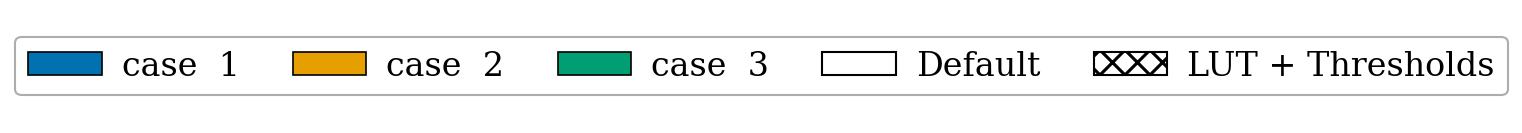

In [193]:
# ================================================================
# Legend handles
# ================================================================
case_legend_handles = [
    Patch(
        facecolor=colors[index],
        edgecolor="black",
        linewidth=0.8,
        label=configs[index]
    )
    for index in range(num_configs)
]

implementation_legend_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        hatch=IMPLEMENTATION_STYLES[name]["hatch"],
        label=IMPLEMENTATION_STYLES[name]["label"]
    )
    for name in implementation_order
    if name in implementations_present
]

handles = (
    case_legend_handles +
    implementation_legend_handles
)

labels = (
    [h.get_label() for h in case_legend_handles] +
    [h.get_label() for h in implementation_legend_handles]
)


# ================================================================
# Legend-only figure
# ================================================================
fig = plt.figure(figsize=(9, 0.9))
ax = fig.add_subplot(111)
ax.axis("off")

legend = ax.legend(
    handles,
    labels,
    loc="center",
    ncol=len(handles),        # all entries on one row
    frameon=True,
    fontsize=16,
    columnspacing=1.6,
    handlelength=2.2,
    handletextpad=0.6,
    edgecolor="0.6",
)

plt.show()

plt.close(fig)

### MACs:

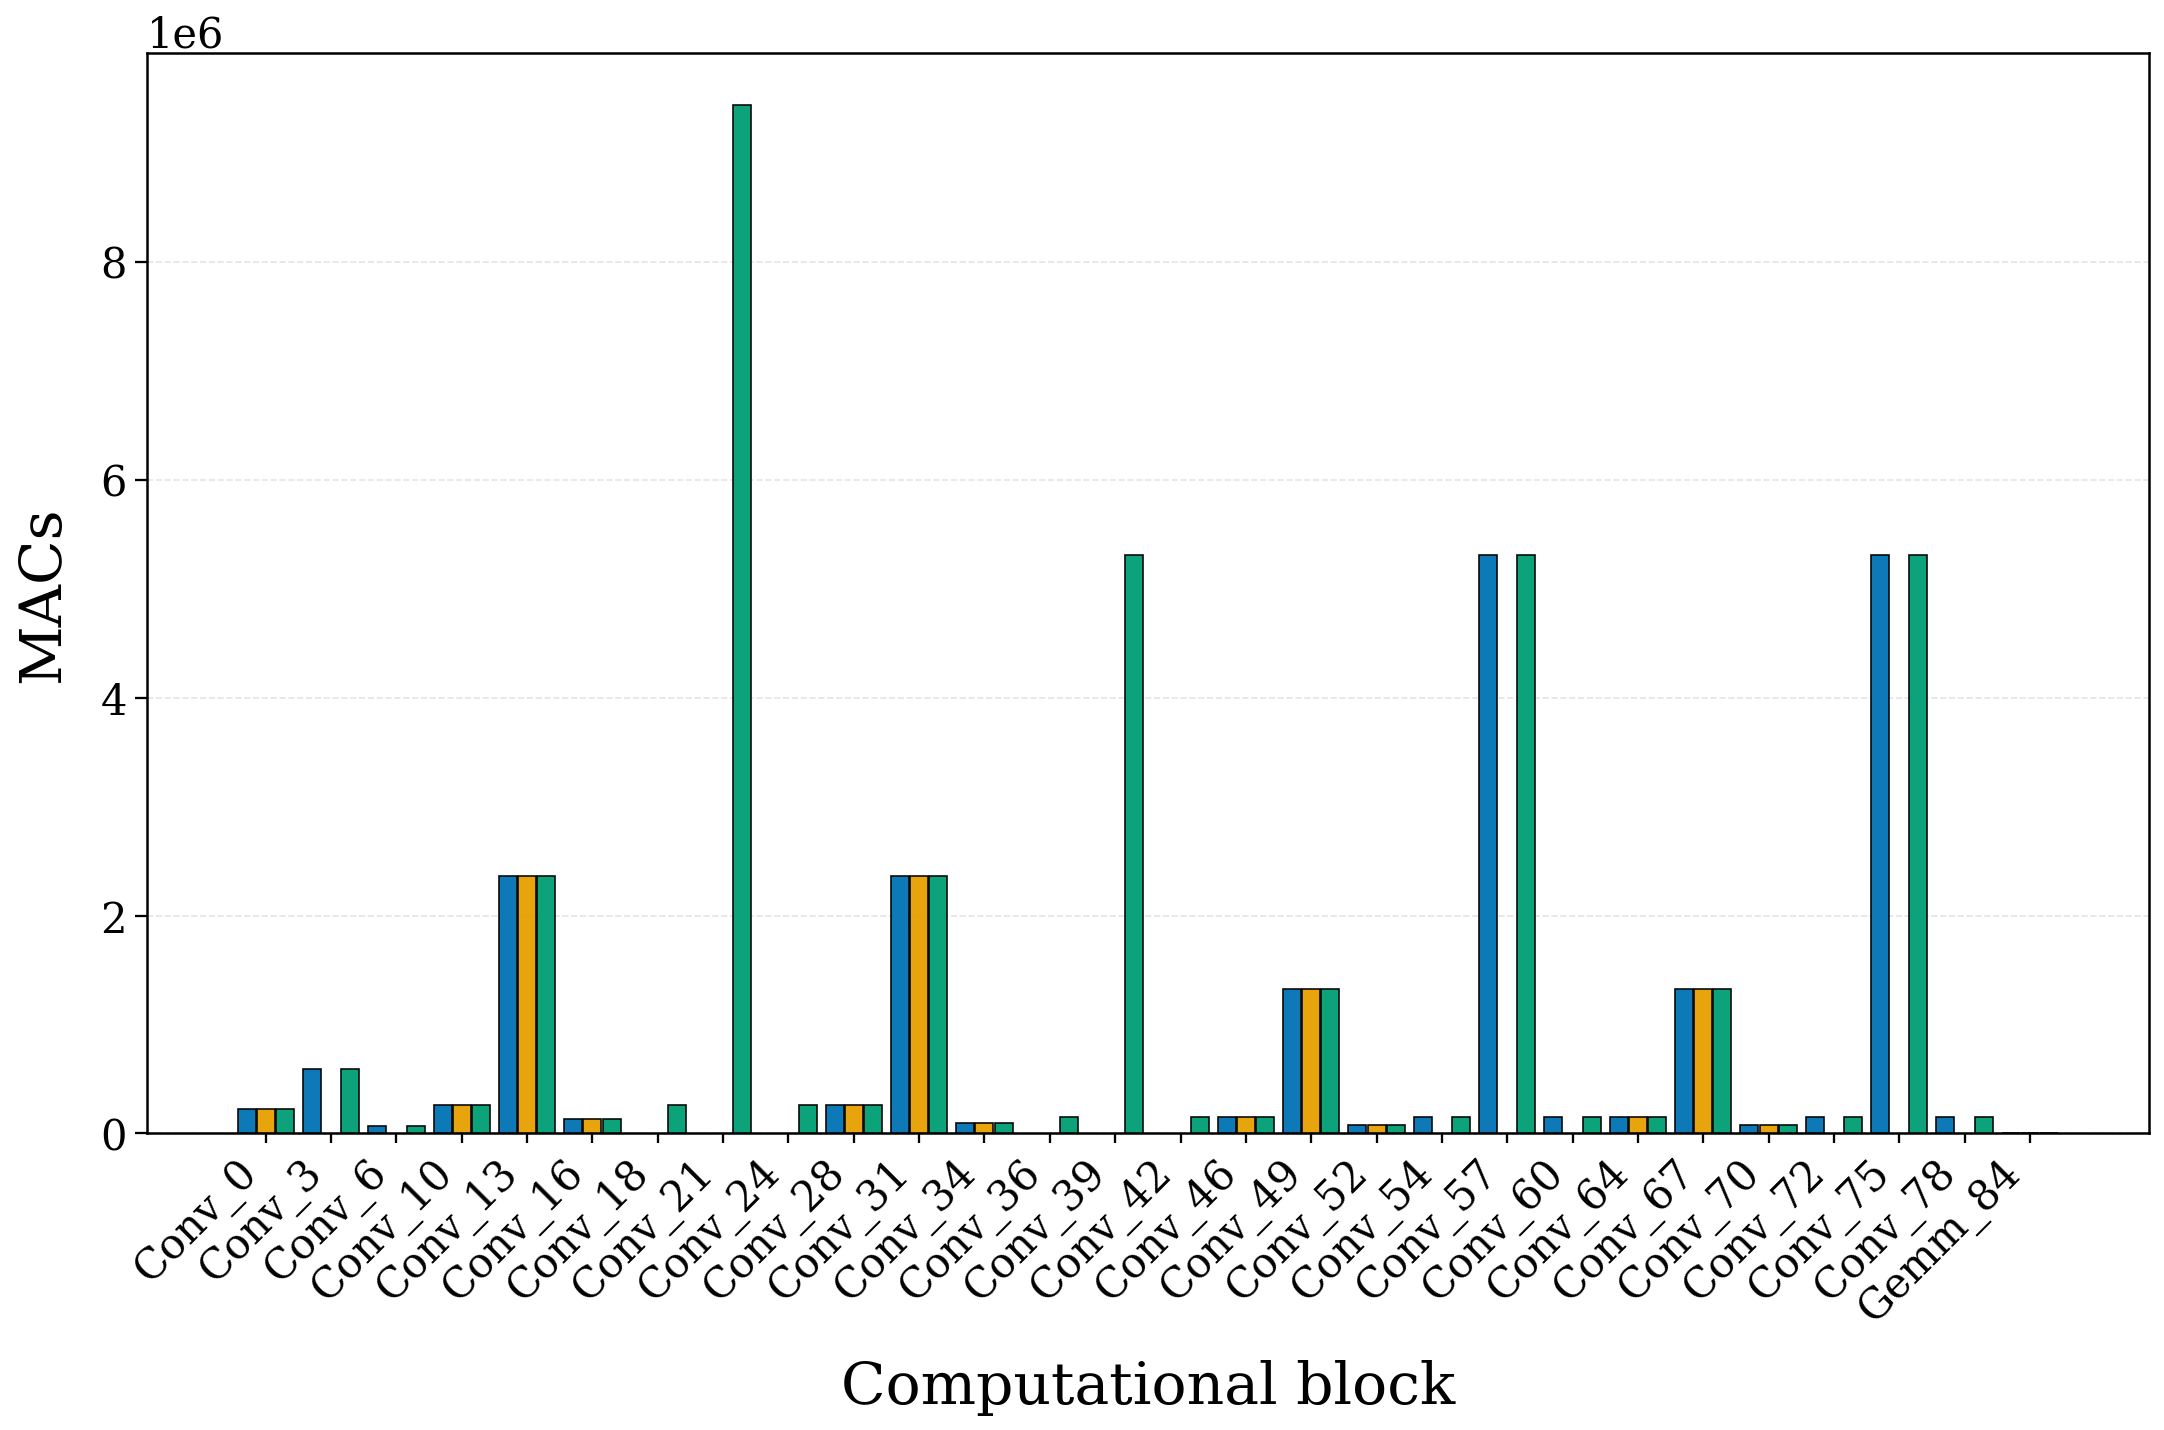

In [194]:
# ================================================================
# Plot 1: MACs
# ================================================================
fig, ax = plt.subplots(
    figsize=FIGURE_SIZE
)

draw_block_bars(
    ax=ax,
    values=mac_plot_values,
    implementations=mac_plot_implementations
)

format_axis(
    ax=ax,
    labels=mac_plot_labels,
    ylabel="MACs",
    logarithmic=False
)

ax.ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(0, 0)
)

# add_combined_legend(ax)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.97,
    bottom=0.25
)

plt.savefig(
    f"./output/images/{model_name}-mac.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)



plt.show()
plt.close(fig)



### Memory

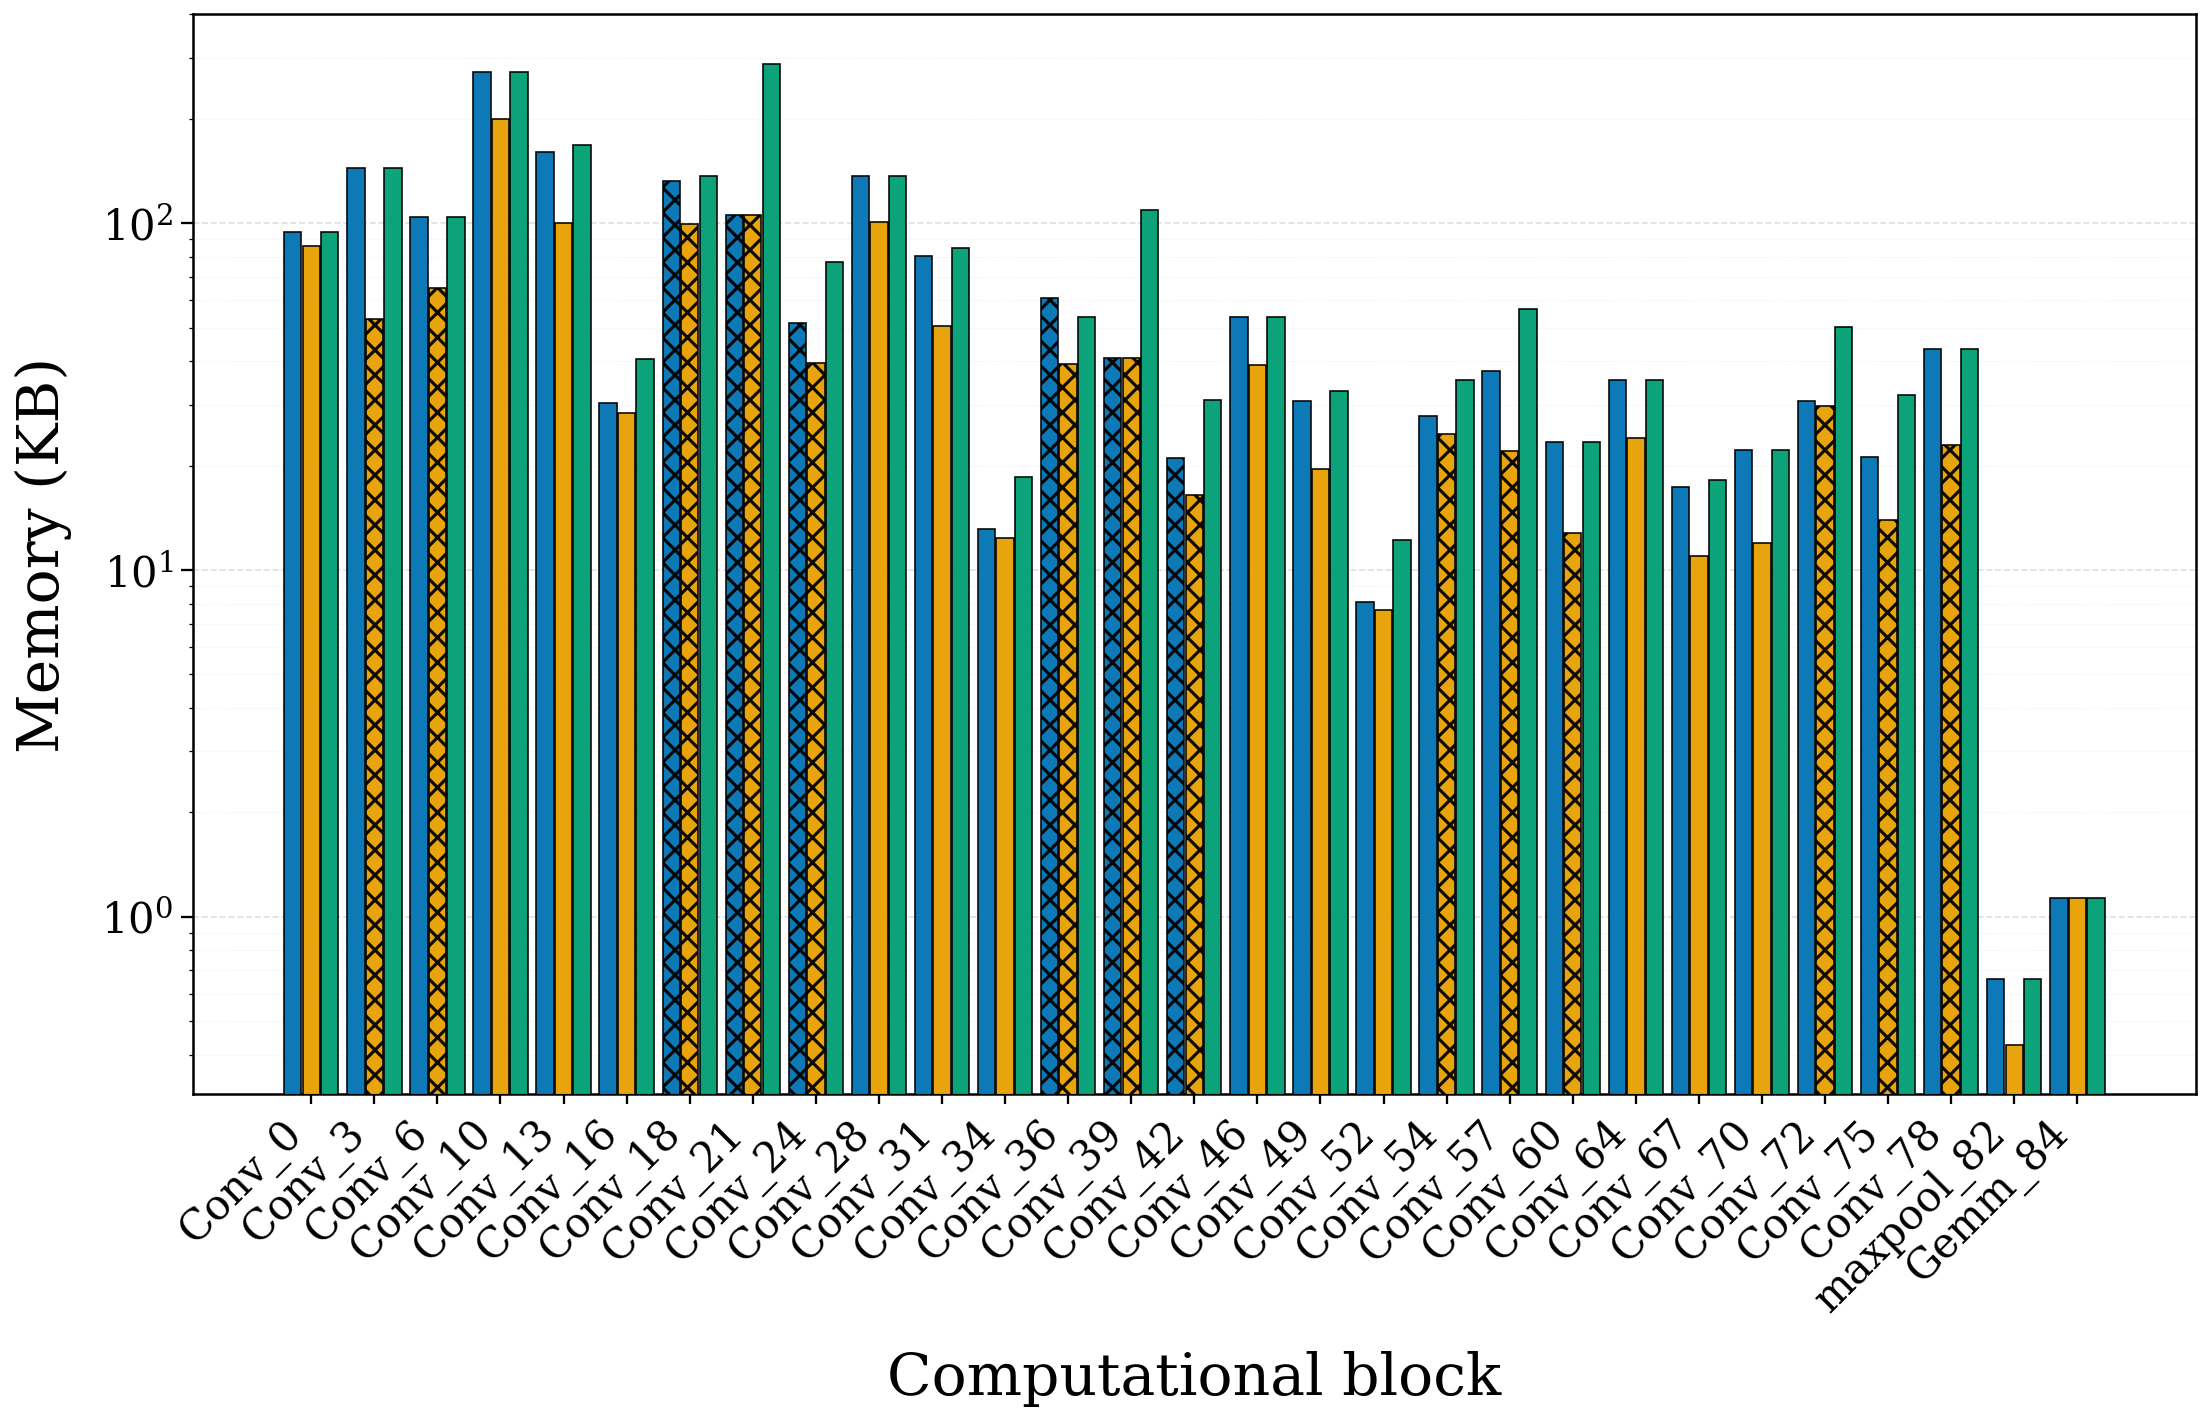

In [195]:
fig, ax = plt.subplots(
    figsize=FIGURE_SIZE
)

memory_plot_values = memory_values_kb.copy()
memory_plot_values[memory_plot_values <= 0] = np.nan

draw_block_bars(
    ax=ax,
    values=memory_plot_values,
    implementations=block_implementations
)

format_axis(
    ax=ax,
    labels=block_labels,
    ylabel="Memory (KB)",
    logarithmic=True
)

# add_combined_legend(ax)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.97,
    bottom=0.25
)

plt.savefig(
    f"./output/images/{model_name}-mem.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


### BOPs

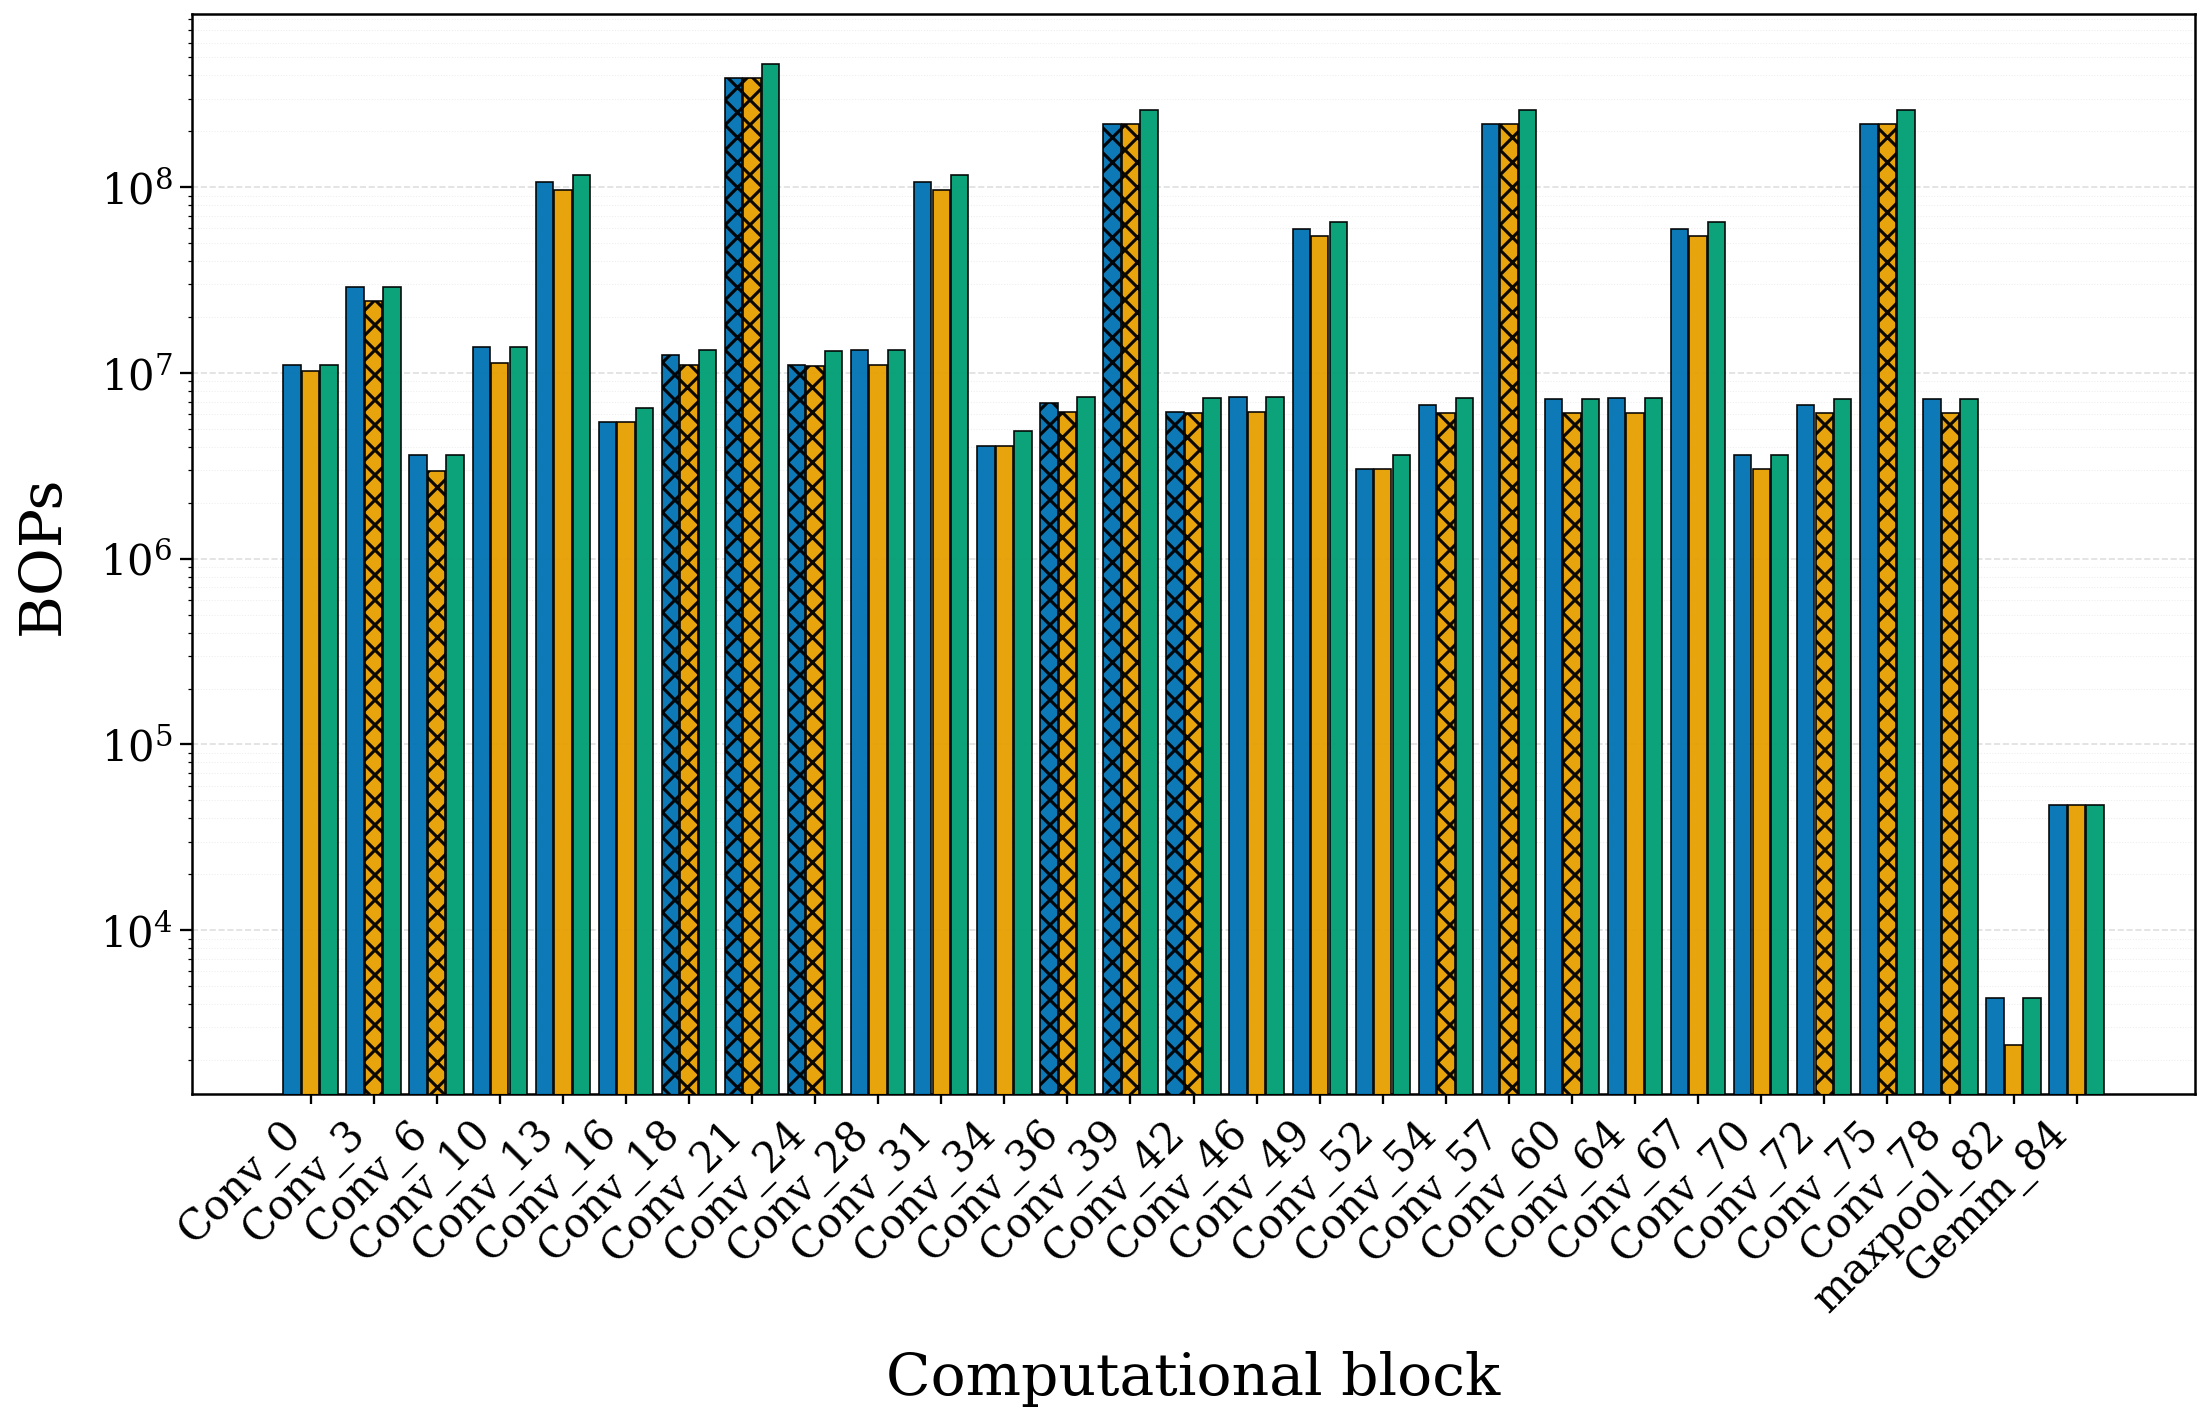

In [196]:
fig, ax = plt.subplots(
    figsize=FIGURE_SIZE
)

bops_plot_values = bops_values.copy()
bops_plot_values[bops_plot_values <= 0] = np.nan

draw_block_bars(
    ax=ax,
    values=bops_plot_values,
    implementations=block_implementations
)

format_axis(
    ax=ax,
    labels=block_labels,
    ylabel="BOPs",
    logarithmic=True
)

# add_combined_legend(ax)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.97,
    bottom=0.25
)

plt.savefig(
    f"./output/images/{model_name}-bop.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

## Implementation Analysis

### Comparison between different cases

### HW-codesign